In [7]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [8]:
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD  = (0.5, 0.5, 0.5)

def get_cifar10_loaders(batch_size=128, num_workers=2, val_size=5000, seed=SEED):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])

    full_train_aug   = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    full_train_noaug = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_eval)
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_eval)

    n = len(full_train_aug)
    indices = list(range(n))
    rng = np.random.RandomState(seed)
    rng.shuffle(indices)
    val_idx, train_idx = indices[:val_size], indices[val_size:]

    train_subset = Subset(full_train_aug, train_idx)
    val_subset   = Subset(full_train_noaug, val_idx)

    trainloader = DataLoader(train_subset, batch_size=batch_size,
                             shuffle=True, num_workers=num_workers,
                             pin_memory=True, drop_last=True)
    valloader   = DataLoader(val_subset,   batch_size=256,
                             shuffle=False, num_workers=num_workers,
                             pin_memory=True)
    testloader  = DataLoader(testset,      batch_size=256,
                             shuffle=False, num_workers=num_workers,
                             pin_memory=True)
    return trainloader, valloader, testloader


In [9]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_branches=4):
        super().__init__()
        self.num_branches = num_branches
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ) for _ in range(num_branches)
        ])
        self.weight_fc = nn.Linear(in_channels, num_branches)

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        a = F.softmax(self.weight_fc(m), dim=1)
        branch_out = torch.stack([b(x) for b in self.branches], dim=1)
        a_view = a.view(a.size(0), a.size(1), 1, 1, 1)
        return (a_view * branch_out).sum(dim=1)


class CustomCNN(nn.Module):
    def __init__(self, num_classes=10, num_branches=4):
        super().__init__()
        self.b1 = IntermediateBlock(3,   128, num_branches)
        self.pool1 = nn.MaxPool2d(2)
        self.b2 = IntermediateBlock(128, 256, num_branches)
        self.pool2 = nn.MaxPool2d(2)
        self.b3 = IntermediateBlock(256, 256, num_branches)
        self.pool3 = nn.MaxPool2d(2)
        self.b4 = IntermediateBlock(256, 256, num_branches)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.pool1(self.b1(x))
        x = self.pool2(self.b2(x))
        x = self.pool3(self.b3(x))
        x = self.b4(x)
        m = x.mean(dim=(2, 3))
        return self.classifier(m)

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)


In [10]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, batch_losses=None):
    model.train()
    running_loss = correct = total = 0
    for inputs, targets in loader:
        inputs  = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()

        if batch_losses is not None:
            batch_losses.append(loss.item())

        running_loss += loss.item() * inputs.size(0)
        correct += outputs.max(1)[1].eq(targets).sum().item()
        total += targets.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss = correct = total = 0
    for inputs, targets in loader:
        inputs  = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        running_loss += loss.item() * inputs.size(0)
        correct += outputs.max(1)[1].eq(targets).sum().item()
        total += targets.size(0)
    return running_loss / total, correct / total


In [11]:
def train_model(epochs=150, batch_size=128, lr=0.1, weight_decay=5e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    trainloader, valloader, testloader = get_cifar10_loaders(batch_size=batch_size)

    model = CustomCNN().to(device)
    model.apply(init_weights)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                          weight_decay=weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    batch_losses = []
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, trainloader, optimizer, loss_fn, device,
            batch_losses=batch_losses)
        val_loss, val_acc = evaluate(model, valloader, loss_fn, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc * 100)
        history['val_acc'].append(val_acc * 100)


        if val_acc * 100 > best_val_acc:
            best_val_acc = val_acc * 100
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1:3d}/{epochs}  "
              f"lr={optimizer.param_groups[0]['lr']:.4f}  "
              f"train_loss={train_loss:.4f}  "
              f"train_acc={train_acc*100:5.2f}%  val_acc={val_acc*100:5.2f}%  "
              f"(best_val={best_val_acc:.2f}%)")


    if best_state is not None:
        model.load_state_dict(best_state)
    test_loss, test_acc = evaluate(model, testloader, loss_fn, device)
    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
    print(f"Test accuracy of best-validation checkpoint: {test_acc*100:.2f}%")


    fig, axes = plt.subplots(1, 3, figsize=(18, 5))


    axes[0].plot(batch_losses, linewidth=0.5)
    axes[0].set_title("Training loss per batch")
    axes[0].set_xlabel("Batch"); axes[0].set_ylabel("Loss")


    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Validation')
    axes[1].axhline(test_acc * 100, color='k', ls='--', lw=1,
                    label=f'Final test = {test_acc*100:.2f}%')
    axes[1].set_title("Accuracy per epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()


    axes[2].plot(history['train_loss'], label='Train')
    axes[2].plot(history['val_loss'],   label='Validation')
    axes[2].set_title("Loss per epoch")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120)
    plt.show()

    return model, history, batch_losses, best_val_acc, test_acc * 100


Using device: cuda
Epoch   1/150  lr=0.1000  train_loss=1.5880  train_acc=40.66%  val_acc=54.42%  (best_val=54.42%)
Epoch   2/150  lr=0.1000  train_loss=1.2043  train_acc=57.15%  val_acc=59.40%  (best_val=59.40%)
Epoch   3/150  lr=0.0999  train_loss=1.0184  train_acc=64.16%  val_acc=65.10%  (best_val=65.10%)
Epoch   4/150  lr=0.0998  train_loss=0.8997  train_acc=68.99%  val_acc=63.22%  (best_val=65.10%)
Epoch   5/150  lr=0.0997  train_loss=0.8154  train_acc=72.52%  val_acc=68.08%  (best_val=68.08%)
Epoch   6/150  lr=0.0996  train_loss=0.7528  train_acc=74.76%  val_acc=72.74%  (best_val=72.74%)
Epoch   7/150  lr=0.0995  train_loss=0.7127  train_acc=75.91%  val_acc=69.38%  (best_val=72.74%)
Epoch   8/150  lr=0.0993  train_loss=0.6773  train_acc=77.48%  val_acc=76.50%  (best_val=76.50%)
Epoch   9/150  lr=0.0991  train_loss=0.6556  train_acc=77.92%  val_acc=76.10%  (best_val=76.50%)
Epoch  10/150  lr=0.0989  train_loss=0.6351  train_acc=78.81%  val_acc=72.10%  (best_val=76.50%)
Epoch  11/1

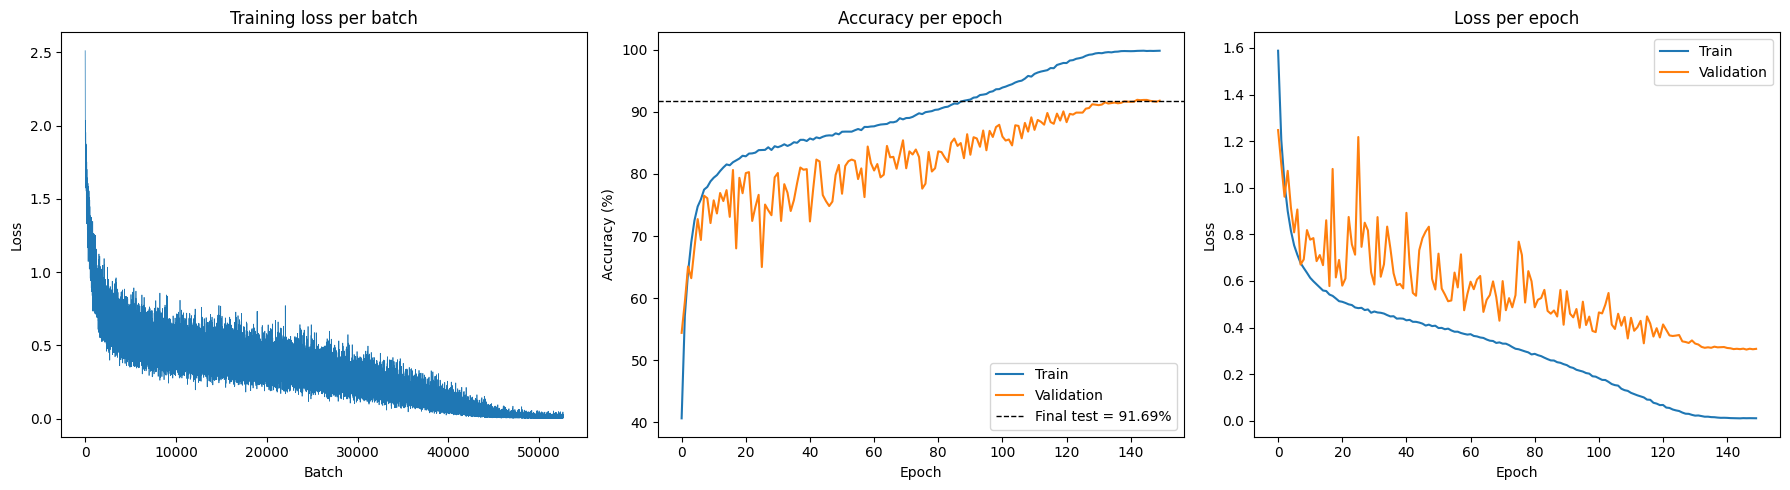


FINAL TEST ACCURACY: 91.69%


In [12]:
model, history, batch_losses, best_val_acc, test_acc = train_model(epochs=150)
print(f"\nFINAL TEST ACCURACY: {test_acc:.2f}%")
